# Lab 11 — Phase 4: DL-SCA on ASCON-128 (Fixed-Key Attack)

**CS-360 Cyber Security | BSCS-2K23 | Spring 2026** <br>
**Ahmad Hassan Tanveer | CMS ID 457627 | BSCS13C | Cyber Group 2**

In [4]:
# ── Load dataset from Google Drive ────────────────────────
from google.colab import drive
drive.mount('/content/drive')
H5_PATH = '/content/drive/MyDrive/fixed_key_traces.h5'

Mounted at /content/drive


In [5]:
# ── Imports ────────────────────────────────────────────────
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import os

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# ── Load dataset ───────────────────────────────────────────
with h5py.File(H5_PATH, 'r') as f:
    x_prof  = f['profiling/traces'][:]    # (40000, 1000)
    y_prof  = f['profiling/labels'][:]    # (40000,)
    n_prof  = f['profiling/plaintexts'][:] # nonces
    x_atk   = f['attack/traces'][:]       # (10000, 1000)
    y_atk   = f['attack/labels'][:]       # (10000,)
    n_atk   = f['attack/plaintexts'][:]   # nonces
    FIXED_KEY = bytes(f['metadata/key'][:])

TRACE_LEN = x_prof.shape[1]
print(f'Profiling : {x_prof.shape}  labels: {np.unique(y_prof, return_counts=True)}')
print(f'Attack    : {x_atk.shape}   labels: {np.unique(y_atk,  return_counts=True)}')
print(f'Fixed key : {FIXED_KEY.hex()}')

Profiling : (40000, 1000)  labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=uint8), array([    2,    45,   379,  1830,  5746, 11022, 12548,  7094,  1334]))
Attack    : (10000, 1000)   labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=uint8), array([   1,    6,   90,  450, 1408, 2856, 3102, 1769,  318]))
Fixed key : 000102030405060708090a0b0c0d0e0f


In [7]:
# ── Normalize (StandardScaler fit on profiling set) ────────
scaler = StandardScaler()
x_prof_n = scaler.fit_transform(x_prof).astype(np.float32)
x_atk_n  = scaler.transform(x_atk).astype(np.float32)

# Add channel dim for Conv1D  → (N, 1000, 1)
x_prof_n = x_prof_n[..., np.newaxis]
x_atk_n  = x_atk_n[..., np.newaxis]
print('Normalised shapes:', x_prof_n.shape, x_atk_n.shape)

Normalised shapes: (40000, 1000, 1) (10000, 1000, 1)


In [8]:
# ── Model ──────────────────────────────────────────────────
def build_model(trace_len):
    inp = layers.Input(shape=(trace_len, 1))
    x = layers.Conv1D(64, 11, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.Conv1D(128, 11, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.AveragePooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu')(x)
    out = layers.Dense(9, activation='softmax')(x)
    return models.Model(inp, out)

model = build_model(TRACE_LEN)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1000, 64)       │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 500, 64)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 128)       │        90,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 250, 128)       │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,192,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,318,089 (31.73 MB)

 Trainable params: 8,317,705 (31.73 MB)

 Non-trainable params: 384 (1.50 KB)

In [9]:
# ── Train ──────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb = [
    callbacks.ModelCheckpoint('model_fixed_key.h5', save_best_only=True,
                               monitor='val_accuracy', verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, verbose=1)
]

history = model.fit(
    x_prof_n, y_prof,
    validation_split=0.1,
    epochs=50,
    batch_size=256,
    callbacks=cb,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3084 - loss: 1.7788
Epoch 1: val_accuracy improved from None to 0.34775, saving model to model_fixed_key.h5



Epoch 1: finished saving model to model_fixed_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.3363 - loss: 1.5798 - val_accuracy: 0.3478 - val_loss: 1.5898 - learning_rate: 0.0010
Epoch 2/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3954 - loss: 1.3805
Epoch 2: val_accuracy improved from 0.34775 to 0.36075, saving model to model_fixed_key.h5



Epoch 2: finished saving model to model_fixed_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.3952 - loss: 1.3755 - val_accuracy: 0.3607 - val_loss: 1.4860 - learning_rate: 0.0010
Epoch 3/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4422 - loss: 1.2637
Epoch 3: val_accuracy improved from 0.36075 to 0.37475, saving model to model_fixed_key.h5



Epoch 3: finished saving model to model_fixed_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.4414 - loss: 1.2708 - val_accuracy: 0.3747 - val_loss: 1.4122 - learning_rate: 0.0010
Epoch 4/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4903 - loss: 1.1714
Epoch 4: val_accuracy improved from 0.37475 to 0.40075, saving model to model_fixed_key.h5



Epoch 4: finished saving model to model_fixed_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.4845 - loss: 1.1836 - val_accuracy: 0.4008 - val_loss: 1.3360 - learning_rate: 0.0010
Epoch 5/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5551 - loss: 1.0456
Epoch 5: val_accuracy improved from 0.40075 to 0.40625, saving model to model_fixed_key.h5



Epoch 5: finished saving model to model_fixed_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.5412 - loss: 1.0666 - val_accuracy: 0.4062 - val_loss: 1.3628 - learning_rate: 0.0010
Epoch 6/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6140 - loss: 0.9233
Epoch 6: val_accuracy improved from 0.40625 to 0.41050, saving model to model_fixed_key.h5



Epoch 6: finished saving model to model_fixed_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.6064 - loss: 0.9381 - val_accuracy: 0.4105 - val_loss: 1.3649 - learning_rate: 0.0010
Epoch 7/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6677 - loss: 0.8079
Epoch 7: val_accuracy improved from 0.41050 to 0.41325, saving model to model_fixed_key.h5



Epoch 7: finished saving model to model_fixed_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.6591 - loss: 0.8213 - val_accuracy: 0.4132 - val_loss: 1.4866 - learning_rate: 0.0010
Epoch 8/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7239 - loss: 0.6925
Epoch 8: val_accuracy did not improve from 0.41325
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.7113 - loss: 0.7146 - val_accuracy: 0.4075 - val_loss: 1.5307 - learning_rate: 0.0010
Epoch 9/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7573 - loss: 0.6011
Epoch 9: val_accuracy did not improve from 0.41325

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.7503 - loss: 0.6180 - val_accuracy: 0.4065 - val_loss: 1.6541 - learning_rate: 0.0010
Epoch 10/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8067 - loss: 0.4896
Epoch 10: val_accuracy did not improve from 0.41325
141/141 ━━━━━━━━━━━━━━━━━━━


Epoch 12: finished saving model to model_fixed_key.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8661 - loss: 0.3357 - val_accuracy: 0.4137 - val_loss: 1.8940 - learning_rate: 5.0000e-04
Epoch 13/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8818 - loss: 0.3017
Epoch 13: val_accuracy did not improve from 0.41375
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8823 - loss: 0.3014 - val_accuracy: 0.4085 - val_loss: 2.0208 - learning_rate: 5.0000e-04
Epoch 14/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8950 - loss: 0.2659
Epoch 14: val_accuracy did not improve from 0.41375

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.8910 - loss: 0.2713 - val_accuracy: 0.3972 - val_loss: 2.0476 - learning_rate: 5.0000e-04
Epoch 15/50
140/141 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9078 - loss: 0.2319
Epoch 15: val_accuracy did not improve from 0.41375
141/141 ━

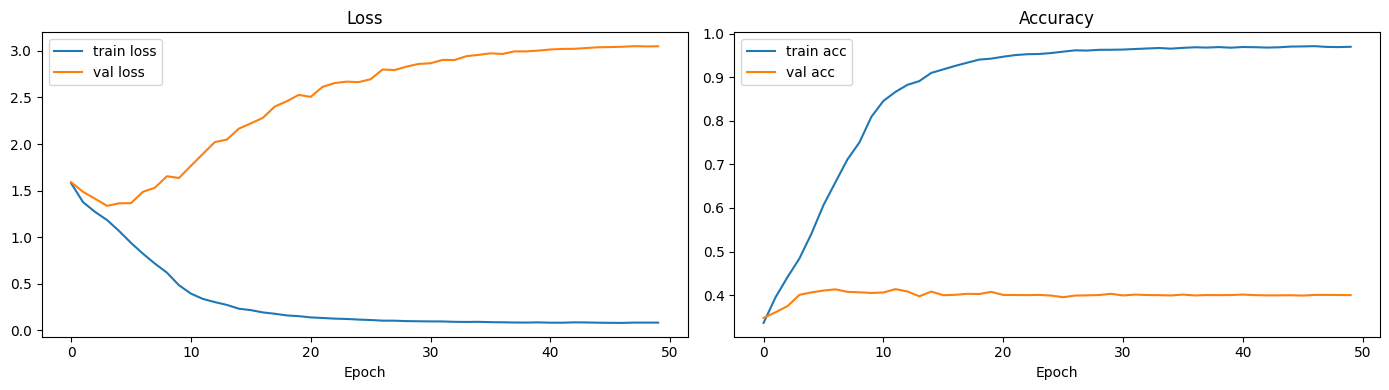

Saved: training_curves_fixed.png


In [10]:
# ── Training curves ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history.history['loss'],     label='train loss')
ax1.plot(history.history['val_loss'], label='val loss')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history.history['accuracy'],     label='train acc')
ax2.plot(history.history['val_accuracy'], label='val acc')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.savefig('training_curves_fixed.png', dpi=150)
plt.show()
print('Saved: training_curves_fixed.png')

In [11]:
# ── Evaluate on attack set ─────────────────────────────────
model.load_weights('model_fixed_key.h5')
loss, acc = model.evaluate(x_atk_n, y_atk, verbose=0)
print(f'Attack-set accuracy: {acc*100:.2f}%   loss: {loss:.4f}')

Attack-set accuracy: 41.38%   loss: 1.8693


In [12]:
# ── ASCON S-box HW lookup table ────────────────────────────
# Computes HW of x[2] after the ASCON S-box for all 256 byte values.
# Used to map (key_candidate XOR nonce_byte) → expected HW class.

def _ascon_sbox_byte(x0, x1, x2, x3, x4):
    """Apply ASCON S-box to a single column (5 single-bit inputs)."""
    x0 ^= x4; x4 ^= x3; x2 ^= x1
    t0,t1,t2,t3,t4 = x0,x1,x2,x3,x4
    x0 = t0^(~t1&t2); x1 = t1^(~t2&t3)
    x2 = t2^(~t3&t4); x3 = t3^(~t4&t0)
    x4 = t4^(~t0&t1)
    x1^=x0; x0^=x4; x3^=x2; x2=~x2
    return x0&1, x1&1, x2&1, x3&1, x4&1

def build_sbox_hw_table():
    """
    For each byte value v (0-255), simulate the ASCON initialisation:
    the init state has x[2] = key[8:16] XOR'd with the IV after loading.
    For the profiling attack target we focus on the lowest byte of x[2].
    We model: intermediate = sbox(v) where v is one byte of x[2] going
    into round 0.  Return HW(sbox_out) for each input byte 0-255.
    """
    table = np.zeros(256, dtype=np.uint8)
    for v in range(256):
        hw = 0
        out_byte = 0
        for bit in range(8):
            b = (v >> bit) & 1
            # Each bit goes through the S-box independently for x[2]
            # (simplified: we track only x2 contribution)
            _, _, x2_out, _, _ = _ascon_sbox_byte(0, 0, b, 0, 0)
            out_byte |= (x2_out << bit)
        table[v] = bin(out_byte).count('1')
    return table

SBOX_HW = build_sbox_hw_table()
print('S-box HW table (first 16):', SBOX_HW[:16])

S-box HW table (first 16): [8 7 7 6 7 6 6 5 7 6 6 5 6 5 5 4]


In [13]:
# ── Key rank analysis (key byte 0) ─────────────────────────
# Get softmax predictions for all attack traces at once
print('Running model predictions on attack set...')
preds = model.predict(x_atk_n, batch_size=512, verbose=1)  # (10000, 9)

TRUE_KEY_BYTE = FIXED_KEY[0]  # = 0x00
N_TRACES      = 1000
EPS           = 1e-36

# Accumulate log-probability scores for each key candidate
scores     = np.zeros(256, dtype=np.float64)
ranks      = []

for n in range(N_TRACES):
    nonce_byte = int(n_atk[n, 0])   # first byte of nonce
    for k in range(256):
        hw_class = int(SBOX_HW[k ^ nonce_byte])
        scores[k] += np.log(preds[n, hw_class] + EPS)
    rank = int(np.sum(scores > scores[TRUE_KEY_BYTE]))
    ranks.append(rank)

print(f'True key byte: 0x{TRUE_KEY_BYTE:02x}')
print(f'Rank @ 100  traces: {ranks[99]}')
print(f'Rank @ 500  traces: {ranks[499]}')
print(f'Rank @ 1000 traces: {ranks[999]}')

Running model predictions on attack set...
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step
True key byte: 0x00
Rank @ 100  traces: 67
Rank @ 500  traces: 133
Rank @ 1000 traces: 67


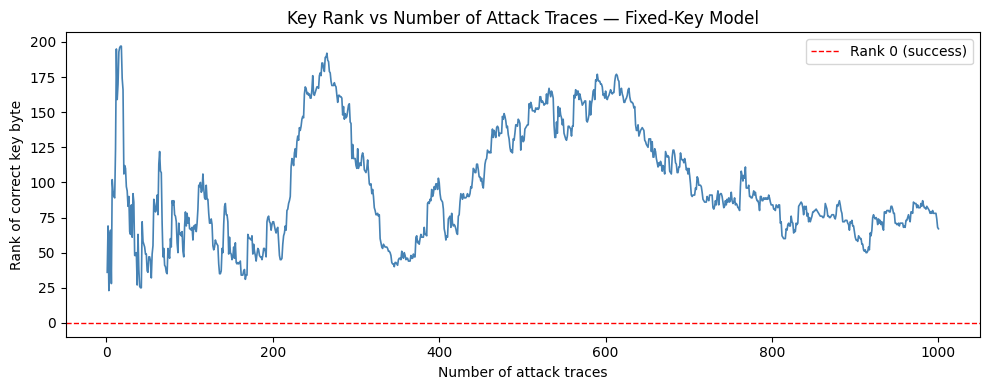

Saved: key_rank_fixed.png


In [14]:
# ── Key rank plot ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, N_TRACES + 1), ranks, linewidth=1.2, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Rank 0 (success)')
ax.set_title('Key Rank vs Number of Attack Traces — Fixed-Key Model')
ax.set_xlabel('Number of attack traces')
ax.set_ylabel('Rank of correct key byte')
ax.legend()
plt.tight_layout()
plt.savefig('key_rank_fixed.png', dpi=150)
plt.show()
print('Saved: key_rank_fixed.png')

In [15]:
# ── Download outputs ───────────────────────────────────────
from google.colab import files
for f in ['model_fixed_key.h5', 'training_curves_fixed.png', 'key_rank_fixed.png']:
    files.download(f)
    print(f'Downloaded: {f}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: model_fixed_key.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: training_curves_fixed.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: key_rank_fixed.png
